# RL Trading From Scratch (Notebook-first)

这个 notebook 从 **0 开始**构建你的作业。

本阶段目标（Phase 1）：
1. 实现均值回复价格模拟环境。
2. 同时支持 `Reward (1)` 和 `Reward (2)`。
3. 用随机策略做 Monte Carlo 评估，建立 baseline。
4. 画样本轨迹，先做环境 sanity check。

后续 Phase 2+ 再加入 PPO / TD3。

## 0) RL 在金融里的最小直觉

- **状态 (state)**：你看到的市场信息（这里用 `log(S_t), L_t`，以及 `Reward (2)` 需要的 `A_{t-1}`）。
- **动作 (action)**：你当前持仓 `A_t`（可正可负，且连续）。
- **奖励 (reward)**：本期交易结果，体现收益和风险/成本权衡。
- **策略 (policy)**：从状态映射到动作的函数。
- **目标**：最大化折扣累计收益 `sum(gamma^t * R_t)`。

在金融场景里，RL 的核心就是：
> 学一个动态仓位控制规则，让长期风险调整后的收益更好。

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple, List

# Reproducibility
SEED = 0
rng = np.random.default_rng(SEED)

plt.style.use('seaborn-v0_8-whitegrid')

## 1) 参数与环境定义

In [3]:
@dataclass
class Config:
    # Market params
    kappa: float = 0.2
    sigma: float = 0.1

    # Reward params
    lam: float = 0.01
    gamma: float = 0.95

    # Action bound
    a_max: float = 10.0

    # Episode horizon
    T: int = 200

cfg = Config()
cfg

Config(kappa=0.2, sigma=0.1, lam=0.01, gamma=0.95, a_max=10.0, T=200)

In [4]:
class MeanRevertingStockEnv:
    """
    Price process:
        L_{t+1} = (1-kappa) * L_t + sigma * Z_t,  Z_t ~ N(0,1)
        S_{t+1} = S_t * exp(L_{t+1})

    Reward (1):
        R_t = A_t * (S_{t+1} - S_t) - lam * A_t^2

    Reward (2):
        R_t = A_t * (S_{t+1} - S_t) - lam * (A_t - A_{t-1})^2 * S_t
    """

    def __init__(self, cfg: Config, reward_type: str = 'R1', seed: int = 0):
        assert reward_type in ('R1', 'R2')
        self.cfg = cfg
        self.reward_type = reward_type
        self.rng = np.random.default_rng(seed)
        self.reset()

    def _get_state(self) -> np.ndarray:
        log_s = math.log(self.s)
        if self.reward_type == 'R1':
            return np.array([log_s, self.l], dtype=np.float32)
        return np.array([log_s, self.l, self.a_prev], dtype=np.float32)

    def reset(self) -> np.ndarray:
        self.t = 0
        self.s = 1.0
        self.l = 0.0
        self.a_prev = 0.0
        return self._get_state()

    def step(self, action: float) -> Tuple[np.ndarray, float, bool, Dict]:
        a = float(np.clip(action, -self.cfg.a_max, self.cfg.a_max))

        # Save current values
        s_t = self.s
        l_t = self.l
        a_prev_t = self.a_prev

        # Market transition
        z = self.rng.normal(0.0, 1.0)
        l_next = (1.0 - self.cfg.kappa) * l_t + self.cfg.sigma * z
        s_next = s_t * math.exp(l_next)

        # Reward
        pnl = a * (s_next - s_t)
        if self.reward_type == 'R1':
            reward = pnl - self.cfg.lam * (a ** 2)
        else:
            reward = pnl - self.cfg.lam * ((a - a_prev_t) ** 2) * s_t

        # Update env state
        self.s = s_next
        self.l = l_next
        self.a_prev = a
        self.t += 1
        done = (self.t >= self.cfg.T)

        info = {
            'S_t': s_t,
            'S_next': s_next,
            'L_t': l_t,
            'L_next': l_next,
            'A_t': a,
            'A_prev_t': a_prev_t,
            'pnl': pnl,
        }
        return self._get_state(), float(reward), done, info

## 2) Sanity Check：随机策略跑一条轨迹

如果环境合理，通常会看到：
- `L_t` 围绕 0 波动（均值回复）。
- `S_t` 随 `L_t` 累积波动。
- `Reward (2)` 相比 `Reward (1)` 对动作跳变更敏感。

In [5]:
def random_policy(state: np.ndarray, a_max: float, rng: np.random.Generator) -> float:
    return rng.uniform(-a_max, a_max)


def rollout_once(env: MeanRevertingStockEnv, rng: np.random.Generator) -> pd.DataFrame:
    state = env.reset()
    rows = []
    done = False
    while not done:
        action = random_policy(state, env.cfg.a_max, rng)
        next_state, reward, done, info = env.step(action)
        rows.append({
            't': env.t - 1,
            'S_t': info['S_t'],
            'L_t': info['L_t'],
            'A_t': info['A_t'],
            'reward': reward,
            'pnl': info['pnl'],
        })
        state = next_state
    return pd.DataFrame(rows)


env_r1 = MeanRevertingStockEnv(cfg, reward_type='R1', seed=SEED)
env_r2 = MeanRevertingStockEnv(cfg, reward_type='R2', seed=SEED)

df_r1 = rollout_once(env_r1, rng)
df_r2 = rollout_once(env_r2, rng)

df_r1.head()

,t,S_t,L_t,A_t,reward,pnl
0,0,1.000000,0.000000,2.739234,-0.040376,0.034658
1,1,1.012652,0.012573,-4.604266,-0.197319,0.014673
2,2,1.009465,-0.003152,-9.180530,-1.430862,-0.588041
3,3,1.073518,0.061521,-9.669447,-1.573631,-0.638649
4,4,1.139567,0.059706,6.265405,-0.433857,-0.041304


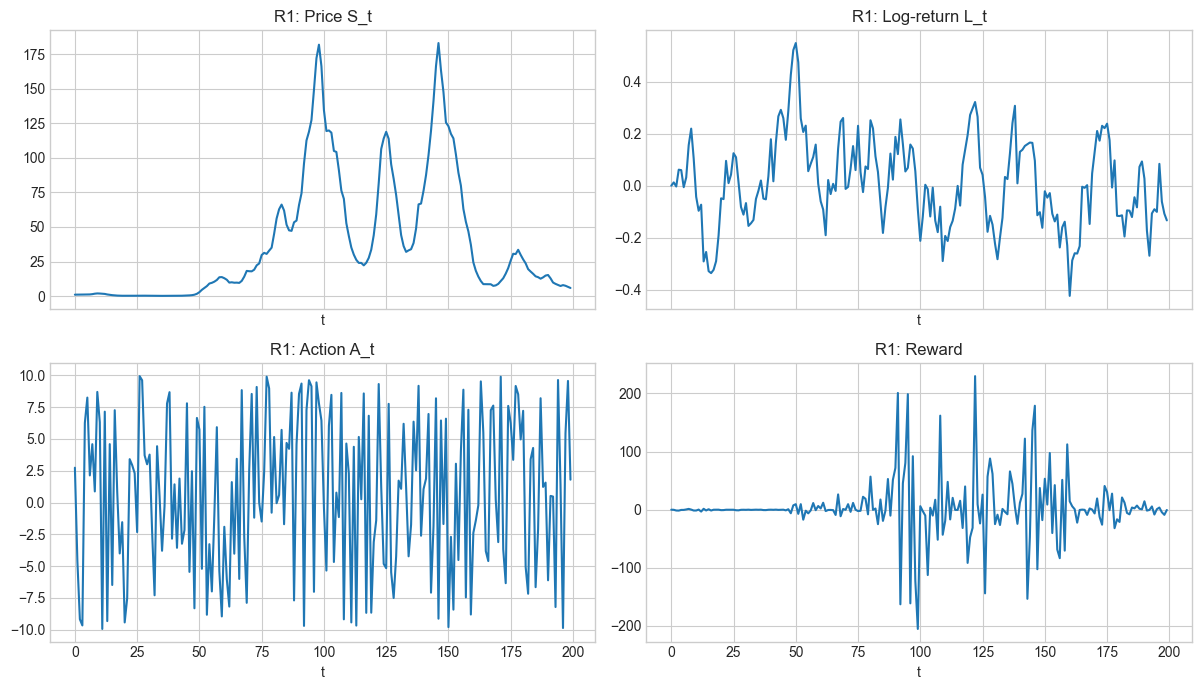

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

axes[0, 0].plot(df_r1['t'], df_r1['S_t'])
axes[0, 0].set_title('R1: Price S_t')
axes[0, 1].plot(df_r1['t'], df_r1['L_t'])
axes[0, 1].set_title('R1: Log-return L_t')

axes[1, 0].plot(df_r1['t'], df_r1['A_t'])
axes[1, 0].set_title('R1: Action A_t')
axes[1, 1].plot(df_r1['t'], df_r1['reward'])
axes[1, 1].set_title('R1: Reward')

for ax in axes.ravel():
    ax.set_xlabel('t')

plt.tight_layout()
plt.show()

## 3) Monte Carlo 评估（随机策略 baseline）

我们先不训练 RL，先评估随机策略。
这一步的意义是：
- 验证评估代码和 discounting 是否正确。
- 给后续 PPO/TD3 一个“必须超越”的基线。

In [7]:
def evaluate_policy_mc(
    cfg: Config,
    reward_type: str,
    policy_fn,
    n_eval: int = 500,
    seed: int = 123,
):
    rng_local = np.random.default_rng(seed)
    returns = []

    for i in range(n_eval):
        env = MeanRevertingStockEnv(cfg, reward_type=reward_type, seed=seed + i)
        state = env.reset()
        done = False
        g = 0.0
        disc = 1.0

        while not done:
            a = policy_fn(state, cfg.a_max, rng_local)
            state, r, done, _ = env.step(a)
            g += disc * r
            disc *= cfg.gamma

        returns.append(g)

    arr = np.array(returns, dtype=np.float64)
    mean_return = arr.mean()
    std_error = arr.std(ddof=1) / np.sqrt(len(arr))
    return {
        'reward_type': reward_type,
        'n_eval': n_eval,
        'mean_return': mean_return,
        'std_error': std_error,
        'return_std': arr.std(ddof=1),
    }


res_r1 = evaluate_policy_mc(cfg, 'R1', random_policy, n_eval=500, seed=2026)
res_r2 = evaluate_policy_mc(cfg, 'R2', random_policy, n_eval=500, seed=3026)

pd.DataFrame([res_r1, res_r2])

,reward_type,n_eval,mean_return,std_error,return_std
0,R1,500,-2264.803907,1439.242404,32182.438519
1,R2,500,-12302.296514,4760.885644,106456.639321


## 4) 结果解释（你该看到什么）

- `R2` 往往比 `R1` 更差（或更保守），因为存在交易成本项。
- 这说明：如果策略频繁调仓，在有成本时会被惩罚。
- 这正是 RL 在金融中的关键：不仅要追收益，还要考虑执行成本和稳定性。

下一阶段我们会做：
1. 加入 `Reward (1)` 理论最优策略（analytic benchmark）。
2. 实现 PPO（先 oracle setting）。
3. 对比随机策略、analytic、PPO。

## 5) Reward (1) 的理论最优策略（Analytic Benchmark）

对于 `Reward (1)`：

$$
R_t = A_t(S_{t+1}-S_t) - \lambda A_t^2
$$

动作不影响未来状态，所以每期可单独优化，得到闭式解：

$$
A_t^* = \frac{S_t\left(e^{(1-\kappa)L_t + 0.5\sigma^2}-1\right)}{2\lambda}
$$

实作中再裁剪到 $[-A_{\max}, A_{\max}]$。

In [8]:
def analytic_policy_r1(
    state: np.ndarray,
    a_max: float,
    rng: np.random.Generator,
    *,
    kappa: float,
    sigma: float,
    lam: float,
) -> float:
    # state for R1: [log_S_t, L_t]
    log_s, l_t = float(state[0]), float(state[1])
    s_t = math.exp(log_s)

    mu_exp = (1.0 - kappa) * l_t + 0.5 * (sigma ** 2)
    m_t = s_t * (math.exp(mu_exp) - 1.0)
    a_star = m_t / (2.0 * lam)
    return float(np.clip(a_star, -a_max, a_max))

## 6) Monte Carlo：随机策略 vs 理论最优策略（仅 Reward 1）

In [9]:
def evaluate_policy_mc_v2(
    cfg: Config,
    reward_type: str,
    policy_fn,
    n_eval: int = 1000,
    seed: int = 123,
    policy_kwargs: Dict = None,
):
    if policy_kwargs is None:
        policy_kwargs = {}

    rng_local = np.random.default_rng(seed)
    returns, avg_abs_pos, turnovers = [], [], []

    for i in range(n_eval):
        env = MeanRevertingStockEnv(cfg, reward_type=reward_type, seed=seed + i)
        state = env.reset()

        done = False
        g = 0.0
        disc = 1.0
        actions = []

        while not done:
            a = policy_fn(state, cfg.a_max, rng_local, **policy_kwargs)
            state, r, done, info = env.step(a)
            g += disc * r
            disc *= cfg.gamma
            actions.append(float(info['A_t']))

        returns.append(g)
        a_arr = np.array(actions, dtype=np.float64)
        avg_abs_pos.append(np.mean(np.abs(a_arr)))

        # A_{-1}=0, so prepend 0 for turnover calculation
        a_prev = np.concatenate([[0.0], a_arr[:-1]])
        turnovers.append(np.mean(np.abs(a_arr - a_prev)))

    arr = np.array(returns, dtype=np.float64)
    return {
        'reward_type': reward_type,
        'n_eval': n_eval,
        'mean_return': float(arr.mean()),
        'std_error': float(arr.std(ddof=1) / np.sqrt(len(arr))),
        'return_std': float(arr.std(ddof=1)),
        'avg_abs_position': float(np.mean(avg_abs_pos)),
        'turnover': float(np.mean(turnovers)),
    }


res_r1_random = evaluate_policy_mc_v2(
    cfg, 'R1', random_policy, n_eval=1000, seed=2026
)

res_r1_analytic = evaluate_policy_mc_v2(
    cfg,
    'R1',
    analytic_policy_r1,
    n_eval=1000,
    seed=2026,
    policy_kwargs={'kappa': cfg.kappa, 'sigma': cfg.sigma, 'lam': cfg.lam},
)

comparison_r1 = pd.DataFrame([
    {'method': 'Random', **res_r1_random},
    {'method': 'Analytic_R1', **res_r1_analytic},
])

benchmark = res_r1_analytic['mean_return']
comparison_r1['relative_to_analytic_%'] = 100.0 * comparison_r1['mean_return'] / benchmark
comparison_r1['regret_vs_analytic'] = benchmark - comparison_r1['mean_return']
comparison_r1

,method,reward_type,n_eval,mean_return,std_error,return_std,avg_abs_position,turnover,relative_to_analytic_%,regret_vs_analytic
0,Random,R1,1000,-1079.29272,740.514308,23417.118520,4.999187,6.646026,-4.403677,25588.19234
1,Analytic_R1,R1,1000,24508.89962,11706.211072,370182.897569,4.812586,2.243989,100.000000,0.00000


## 7) Policy 可视化（Reward 1）

固定 `S_t = 1`，画 `L_t -> A_t`。
这张图是后续对比 PPO/TD3 的标准模板。

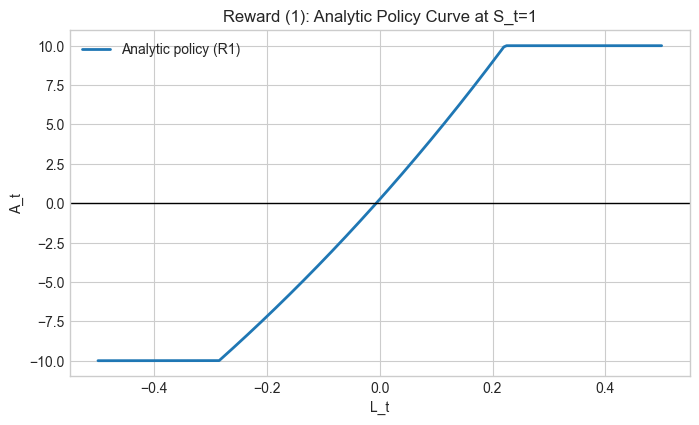

In [10]:
L_grid = np.linspace(-0.5, 0.5, 201)
A_grid = []
for l in L_grid:
    st = np.array([0.0, l], dtype=np.float32)  # log(S)=0 => S=1
    a = analytic_policy_r1(
        st,
        cfg.a_max,
        rng,
        kappa=cfg.kappa,
        sigma=cfg.sigma,
        lam=cfg.lam,
    )
    A_grid.append(a)

plt.figure(figsize=(8, 4.5))
plt.plot(L_grid, A_grid, label='Analytic policy (R1)', lw=2)
plt.axhline(0.0, color='black', lw=1)
plt.xlabel('L_t')
plt.ylabel('A_t')
plt.title('Reward (1): Analytic Policy Curve at S_t=1')
plt.legend()
plt.show()

## 8) 这一步你学到的金融 RL 结论

- 在 `Reward (1)` 下，理论最优策略通常会随着 `L_t` 单调变化：
  `L_t` 越高，对下一期价格上涨的条件期望越高，仓位趋向更大。
- `lambda` 越大，最优仓位幅度越小（风险惩罚更重）。
- 这一节给了我们一个强 benchmark，后面训练 PPO/TD3 可以直接比较 `relative_to_analytic_%` 和 `regret`。

下一节开始进入 `PPO on Reward (1), Oracle setting`。

## 9) PPO（Reward 1, Oracle）

这一步我们训练第一个 RL 策略：
- 环境：`Reward (1)`
- 数据协议：`simulation oracle`（每个 episode 可独立重置）
- 目标：让 learned policy 在 MC 评估上逼近 analytic benchmark。

In [11]:
import random
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device('cpu')

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_global_seed(SEED)

In [12]:
class Actor(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int, a_max: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.log_std = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.a_max = a_max

    def forward(self, x: torch.Tensor):
        mu = self.net(x)
        # Bound mean to action range to avoid unstable large actions.
        mu = torch.tanh(mu) * self.a_max
        std = torch.exp(self.log_std).expand_as(mu)
        return mu, std


class Critic(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor):
        return self.net(x)


def gaussian_log_prob(action, mu, std):
    var = std.pow(2)
    log_scale = torch.log(std)
    return -0.5 * (((action - mu) ** 2) / var + 2 * log_scale + np.log(2 * np.pi))


def compute_gae(rewards, values, dones, last_value, gamma=0.95, lam_gae=0.95):
    T = len(rewards)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        next_value = last_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * (1.0 - dones[t]) * next_value - values[t]
        gae = delta + gamma * lam_gae * (1.0 - dones[t]) * gae
        adv[t] = gae
    ret = adv + values
    return adv, ret

In [13]:
def train_ppo_r1_oracle(
    cfg: Config,
    total_steps: int = 20000,
    rollout_steps: int = 1024,
    hidden_dim: int = 64,
    lr: float = 3e-4,
    gamma: float = 0.95,
    lam_gae: float = 0.95,
    clip_eps: float = 0.2,
    ppo_epochs: int = 10,
    batch_size: int = 128,
    seed: int = 0,
):
    set_global_seed(seed)

    env = MeanRevertingStockEnv(cfg, reward_type='R1', seed=seed)
    state_dim = 2

    actor = Actor(state_dim, hidden_dim, cfg.a_max).to(DEVICE)
    critic = Critic(state_dim, hidden_dim).to(DEVICE)
    opt_actor = optim.Adam(actor.parameters(), lr=lr)
    opt_critic = optim.Adam(critic.parameters(), lr=lr)

    obs = env.reset()
    step_count = 0

    ep_ret = 0.0
    completed_ep_returns = []
    train_log = []

    while step_count < total_steps:
        obs_buf, act_buf, logp_buf = [], [], []
        rew_buf, done_buf, val_buf = [], [], []

        for _ in range(rollout_steps):
            s_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                mu, std = actor(s_t)
                dist = torch.distributions.Normal(mu, std)
                a_t = dist.sample()
                a_t = torch.clamp(a_t, -cfg.a_max, cfg.a_max)
                logp_t = dist.log_prob(a_t).sum(-1)
                v_t = critic(s_t).squeeze(-1)

            action = float(a_t.cpu().numpy().item())
            next_obs, reward, done, _ = env.step(action)

            obs_buf.append(obs.copy())
            act_buf.append([action])
            logp_buf.append(float(logp_t.cpu().numpy().item()))
            rew_buf.append(float(reward))
            done_buf.append(float(done))
            val_buf.append(float(v_t.cpu().numpy().item()))

            ep_ret += reward
            obs = next_obs
            step_count += 1

            if done:
                completed_ep_returns.append(ep_ret)
                ep_ret = 0.0
                obs = env.reset()

            if step_count >= total_steps:
                break

        s_last = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            last_v = float(critic(s_last).cpu().numpy().item())

        adv, ret = compute_gae(
            np.array(rew_buf, dtype=np.float32),
            np.array(val_buf, dtype=np.float32),
            np.array(done_buf, dtype=np.float32),
            last_v,
            gamma=gamma,
            lam_gae=lam_gae,
        )

        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_t = torch.tensor(np.array(obs_buf), dtype=torch.float32, device=DEVICE)
        act_t = torch.tensor(np.array(act_buf), dtype=torch.float32, device=DEVICE)
        old_logp_t = torch.tensor(np.array(logp_buf), dtype=torch.float32, device=DEVICE)
        adv_t = torch.tensor(adv, dtype=torch.float32, device=DEVICE)
        ret_t = torch.tensor(ret, dtype=torch.float32, device=DEVICE)

        n = len(obs_buf)
        idx = np.arange(n)

        for _ in range(ppo_epochs):
            np.random.shuffle(idx)
            for start in range(0, n, batch_size):
                b = idx[start:start + batch_size]

                mu_b, std_b = actor(obs_t[b])
                dist_b = torch.distributions.Normal(mu_b, std_b)
                logp_b = dist_b.log_prob(act_t[b]).sum(-1)
                ratio = torch.exp(logp_b - old_logp_t[b])

                surr1 = ratio * adv_t[b]
                surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv_t[b]
                loss_actor = -torch.min(surr1, surr2).mean()

                v_pred = critic(obs_t[b]).squeeze(-1)
                loss_critic = ((v_pred - ret_t[b]) ** 2).mean()

                opt_actor.zero_grad()
                loss_actor.backward()
                nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
                opt_actor.step()

                opt_critic.zero_grad()
                loss_critic.backward()
                nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
                opt_critic.step()

        mean_recent = float(np.mean(completed_ep_returns[-10:])) if completed_ep_returns else np.nan
        train_log.append({
            'steps': step_count,
            'episodes_done': len(completed_ep_returns),
            'mean_recent_ep_return': mean_recent,
        })

    return actor, critic, pd.DataFrame(train_log), completed_ep_returns

In [14]:
# Fast debug run first; later you can scale to 50k+ steps.
actor_r1_ppo, critic_r1_ppo, ppo_log_r1, ep_returns_r1 = train_ppo_r1_oracle(
    cfg,
    total_steps=12000,
    rollout_steps=1024,
    hidden_dim=64,
    lr=3e-4,
    gamma=cfg.gamma,
    lam_gae=0.95,
    clip_eps=0.2,
    ppo_epochs=8,
    batch_size=128,
    seed=0,
)

ppo_log_r1.tail()

,steps,episodes_done,mean_recent_ep_return
7,8192,40,27792.344873
8,9216,46,157973.797718
9,10240,51,151303.207378
10,11264,56,5064.598747
11,12000,60,630.051436


In [15]:
def ppo_policy_r1(
    state: np.ndarray,
    a_max: float,
    rng: np.random.Generator,
    *,
    actor: Actor,
) -> float:
    s_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        mu, _ = actor(s_t)
    a = float(mu.cpu().numpy().item())
    return float(np.clip(a, -a_max, a_max))


res_r1_ppo = evaluate_policy_mc_v2(
    cfg,
    'R1',
    ppo_policy_r1,
    n_eval=1000,
    seed=4026,
    policy_kwargs={'actor': actor_r1_ppo},
)

comparison_r1_ppo = pd.DataFrame([
    {'method': 'Random', **res_r1_random},
    {'method': 'PPO_R1_Oracle', **res_r1_ppo},
    {'method': 'Analytic_R1', **res_r1_analytic},
])

benchmark = res_r1_analytic['mean_return']
comparison_r1_ppo['relative_to_analytic_%'] = 100.0 * comparison_r1_ppo['mean_return'] / benchmark
comparison_r1_ppo['regret_vs_analytic'] = benchmark - comparison_r1_ppo['mean_return']
comparison_r1_ppo

,method,reward_type,n_eval,mean_return,std_error,return_std,avg_abs_position,turnover,relative_to_analytic_%,regret_vs_analytic
0,Random,R1,1000,-1079.292720,740.514308,23417.118520,4.999187,6.646026,-4.403677,25588.192340
1,PPO_R1_Oracle,R1,1000,21530.077032,21282.529930,673012.689506,0.910943,0.111637,87.845955,2978.822588
2,Analytic_R1,R1,1000,24508.899620,11706.211072,370182.897569,4.812586,2.243989,100.000000,0.000000


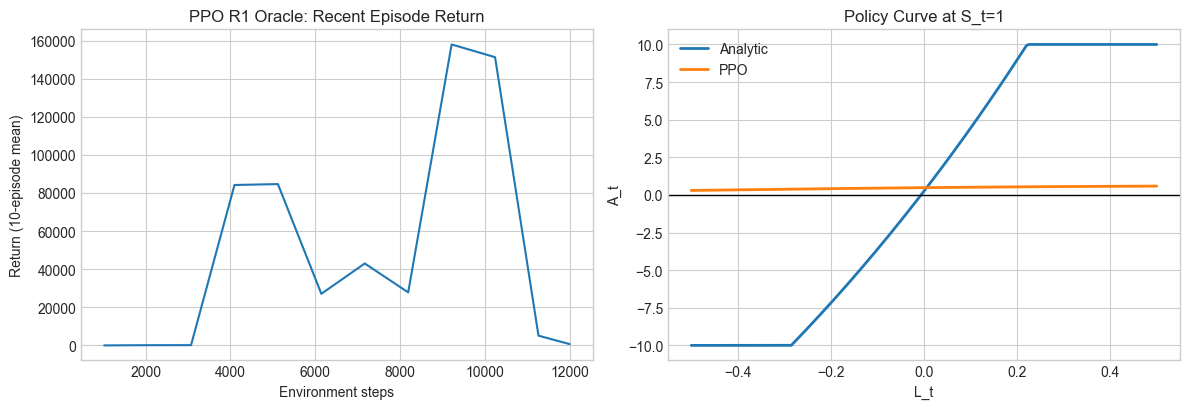

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(ppo_log_r1['steps'], ppo_log_r1['mean_recent_ep_return'])
axes[0].set_title('PPO R1 Oracle: Recent Episode Return')
axes[0].set_xlabel('Environment steps')
axes[0].set_ylabel('Return (10-episode mean)')

# Policy curve comparison at S=1
L_grid = np.linspace(-0.5, 0.5, 201)
A_ana, A_ppo = [], []
for l in L_grid:
    st = np.array([0.0, l], dtype=np.float32)
    A_ana.append(analytic_policy_r1(st, cfg.a_max, rng, kappa=cfg.kappa, sigma=cfg.sigma, lam=cfg.lam))
    A_ppo.append(ppo_policy_r1(st, cfg.a_max, rng, actor=actor_r1_ppo))

axes[1].plot(L_grid, A_ana, label='Analytic', lw=2)
axes[1].plot(L_grid, A_ppo, label='PPO', lw=2)
axes[1].axhline(0.0, color='black', lw=1)
axes[1].set_title('Policy Curve at S_t=1')
axes[1].set_xlabel('L_t')
axes[1].set_ylabel('A_t')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10) 如何解读 PPO 结果

你重点看三件事：
1. `comparison_r1_ppo` 里 PPO 的 `relative_to_analytic_%` 是否上升。
2. `regret_vs_analytic` 是否缩小。
3. policy curve 形状是否逐步贴近 analytic 曲线。

如果结果不稳，先按这个顺序调参：
- 训练步数 `total_steps` 增加到 `30000~80000`。
- 学习率降到 `1e-4`。
- 增大 `rollout_steps`（如 2048）。